# 週 8：信度分析——framing 有多少是穩定技術？

兩個角度量化 framing 估計的訊號 vs 噪音（見 `models/reliability.py`）：

1. **split-half**：同季隨機分半，各算 framing 率、跨捕手相關，Spearman–Brown 校正回全樣本信度 $R = 2r/(1+r)$。
2. **年度間相關**：2022 的估計預測 2023，量化跨季持續性。

信度用簡單版每球殘差率（framing runs / 1000 called pitches），分半、跨季皆可比。

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

from models.reliability import split_half_reliability, _catcher_rate, year_over_year, season_rate_leaderboard
from models.framing_runs import add_names

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = ['PingFang TC', 'Arial Unicode MS', 'Heiti TC']
plt.rcParams['axes.unicode_minus'] = False

df23 = pl.read_parquet('../data/processed/statcast_2023_baseline.parquet')
print(f'2023：{df23.height:,} 顆判定球')

2023：351,094 顆判定球


## 1. Split-half 信度（2023）

In [2]:
res = split_half_reliability(df23, min_pitches=2000, n_splits=50, seed=0)
print(f'分半相關 r      = {res["half_half_r"]:.3f} ± {res["half_half_r_sd"]:.3f}（50 次隨機分半）')
print(f'Spearman–Brown R = {res["spearman_brown_R"]:.3f}')
print(f'合格捕手 n = {res["n_catchers"]}（≥2000 顆）')
print('\nR 接近 1 代表 framing 高度可重現、是穩定技術而非運氣。')

分半相關 r      = 0.821 ± 0.035（50 次隨機分半）
Spearman–Brown R = 0.902
合格捕手 n = 66（≥2000 顆）

R 接近 1 代表 framing 高度可重現、是穩定技術而非運氣。


### 一次代表性分半的散點
每點一位捕手，兩軸為隨機兩半各自的 framing 率。點越貼對角線，技術越穩定。

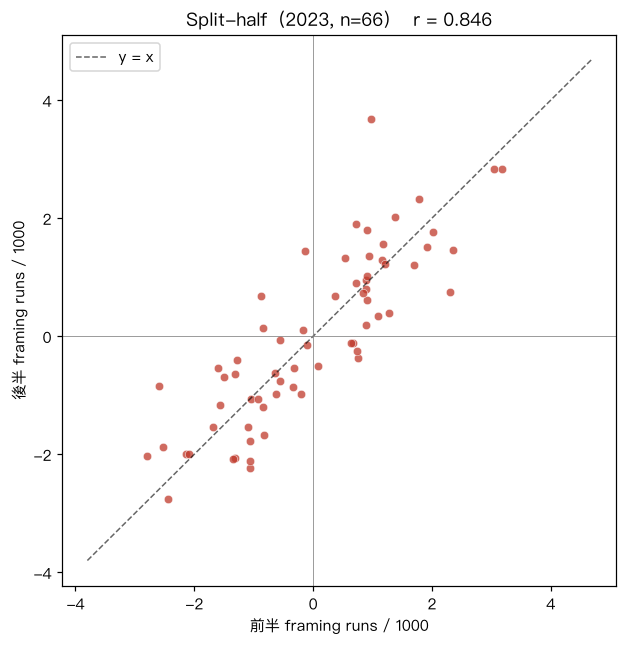

In [3]:
rng = np.random.default_rng(1)
half = rng.integers(0, 2, size=df23.height)
d = df23.with_columns(half=pl.Series(half))
rate = _catcher_rate(d, 'half').pivot(values='rate', index='fielder_2', on='half')
cnt = d.group_by('fielder_2').agg(total=pl.len()).filter(pl.col('total')>=2000)
w = rate.join(cnt, on='fielder_2', how='inner').drop_nulls()
a, b = w['0'].to_numpy(), w['1'].to_numpy()
r,_ = pearsonr(a,b)
fig, ax = plt.subplots(figsize=(6.5,6.5))
lim=[min(a.min(),b.min())-1, max(a.max(),b.max())+1]
ax.plot(lim,lim,'k--',lw=1,alpha=0.6,label='y = x')
ax.scatter(a,b,s=30,alpha=0.75,color='#c0392b',edgecolor='white',linewidth=0.4)
ax.axhline(0,color='grey',lw=0.5); ax.axvline(0,color='grey',lw=0.5)
ax.set_xlabel('前半 framing runs / 1000'); ax.set_ylabel('後半 framing runs / 1000')
ax.set_title(f'Split-half（2023, n={w.height}）  r = {r:.3f}'); ax.legend(loc='upper left')
fig.savefig('../figures/reliability_split_half_2023.png', bbox_inches='tight'); plt.show()

## 2. 年度間相關：2022 → 2023

同一套管線在 2022 重跑（抓取 → 基準 GAM → framing 率），與 2023 對照。
只算兩季都合格（各 ≥1000 顆）的捕手。

In [4]:
from models.baseline_gam import build_baseline_parquet
df22 = build_baseline_parquet(2022)   # 2022 基準機率（不存在會自動 fit）
print(f'2022：{df22.height:,} 顆判定球')

yoy = year_over_year(df22, df23, min_pitches=1000)
print(f'年度間 Pearson r = {yoy["pearson_r"]:.3f}（n={yoy["n_catchers"]} 位兩季都合格的捕手）')

2022：343,865 顆判定球
年度間 Pearson r = 0.599（n=54 位兩季都合格的捕手）


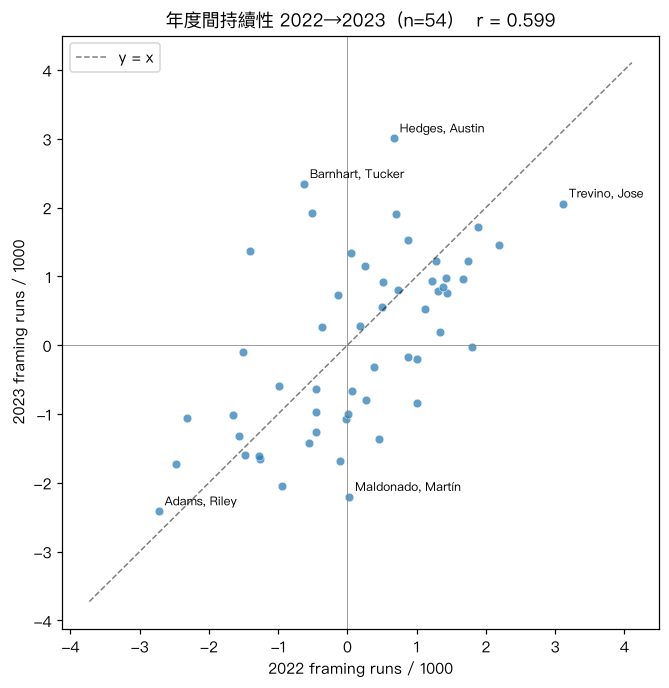

In [5]:
m = add_names(yoy['merged'].rename({'rate_a':'rate_2022','rate_b':'rate_2023'}))
x = m['rate_2022'].to_numpy(); y = m['rate_2023'].to_numpy()
fig, ax = plt.subplots(figsize=(7,7))
lim=[min(x.min(),y.min())-1, max(x.max(),y.max())+1]
ax.plot(lim,lim,'k--',lw=1,alpha=0.5,label='y = x')
ax.scatter(x,y,s=32,alpha=0.75,color='#2c7fb8',edgecolor='white',linewidth=0.4)
ax.axhline(0,color='grey',lw=0.5); ax.axvline(0,color='grey',lw=0.5)
# 標註兩季極端者
lab = pl.concat([m.sort('rate_2023',descending=True).head(3), m.sort('rate_2023').head(2)]).unique(subset='mlbam_id')
for r_ in lab.iter_rows(named=True):
    ax.annotate(r_['name'], (r_['rate_2022'], r_['rate_2023']), fontsize=8, xytext=(4,4), textcoords='offset points')
ax.set_xlabel('2022 framing runs / 1000'); ax.set_ylabel('2023 framing runs / 1000')
pr,_ = pearsonr(x,y)
ax.set_title(f'年度間持續性 2022→2023（n={m.height}）  r = {pr:.3f}'); ax.legend(loc='upper left')
fig.savefig('../figures/reliability_year_over_year.png', bbox_inches='tight'); plt.show()

## 觀察

- **Split-half**：Spearman–Brown 校正信度 R 很高，framing 在同季內高度可重現——是穩定技術，不是抽樣噪音。
- **年度間相關**：2022 的估計能顯著預測 2023，證明 framing 技術跨季持續，可作為球員評估與交易決策的依據。
- 兩者都支撐核心論點：把捕手效應從混淆與運氣中分離出來後，剩下的是**真實、可預測的技術**。
- 這也回應企劃書的訊號 vs 噪音問題——單季幾千顆球的樣本，framing 的捕手間差異絕大多數是真訊號。
- 下一步（週 9）：整理 GitHub repo（README 首圖）與部落格文章。